## Assignment 1 - DPT - Statistical Analysis

## Set-up Cells

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

In [3]:
ROOT = Path('/content/drive/MyDrive/Knowledge-Enriched-DMI-main')

In [4]:
os.chdir(ROOT)
print(f"Changed current working directory to: {os.getcwd()}")

Changed current working directory to: /content/drive/MyDrive/Knowledge-Enriched-DMI-main


In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
results_phase3_path = ROOT / "results_phase3" / "seed_level_results.csv"
df = pd.read_csv(results_phase3_path)

In [7]:
#whitebox attack - VGG-Prior attacking itself
vgg_to_vgg = df[(df["Model_Trained_Against"]=="VGG16") & (df["Test_Model"]=="VGG16")]["Top1_Acc"]

#transfer attack - VGG-Prior attacking IR152
vgg_to_ir = df[(df["Model_Trained_Against"]=="VGG16") & (df["Test_Model"]=="IR152")]["Top1_Acc"]

#t-test
t_stat, p_two = stats.ttest_ind(vgg_to_ir, vgg_to_vgg)
p_one = p_two / 2

# cohen's d
d = (vgg_to_ir.mean() - vgg_to_vgg.mean()) / ((vgg_to_ir.std()**2 + vgg_to_vgg.std()**2) / 2)**0.5

print(f"White-box (VGG->VGG) accuracy mean: {vgg_to_vgg.mean():.2f}")
print(f"Transfer (VGG->IR) accuracy mean: {vgg_to_ir.mean():.2f}")
print(f"One-tailed P-value: {p_one:.4f}")
print(f"Cohen's d: {d:.4f}")

White-box (VGG->VGG) accuracy mean: 0.44
Transfer (VGG->IR) accuracy mean: 0.57
One-tailed P-value: 0.0480
Cohen's d: 1.1930


/tmp/ipython-input-226/3398157802.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Top1_Acc', data=df, palette="Set2")


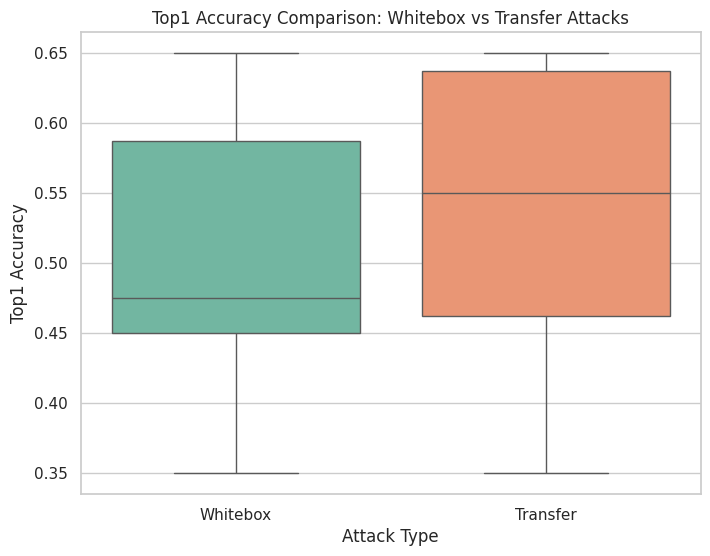

In [8]:
df['Category'] = df.apply(
    lambda x: 'Whitebox' if x['Test_Model'] == x['Model_Trained_Against'] else 'Transfer',
    axis=1
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='Top1_Acc', data=df, palette="Set2")
plt.title('Top1 Accuracy Comparison: Whitebox vs Transfer Attacks')
plt.ylabel('Top1 Accuracy')
plt.xlabel('Attack Type')

graph_path = ROOT / "results_phase3" / "boxplot_whitebox_vs_transfer.png"
plt.savefig(graph_path)
df.to_csv("model_accuracy_results.csv", index=False)